In [4]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [10]:
df = pd.read_csv("C:/Users/braya/Documents/Analisis de datos/Proyecto empresa/FACT_SALES (1).csv", encoding='latin1')
df

,ï»¿WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
0,34-22,7501058792808BP2,0.006,0.139,1.000,TOTAL AUTOS AREA 5
1,34-22,7.50106E+12,0.487,116.519,2.916,TOTAL AUTOS AREA 5
2,34-22,7.70263E+12,1.391,68.453,5.171,TOTAL AUTOS AREA 5
3,34-22,7.50106E+12,0.022,1.481,1.833,TOTAL AUTOS AREA 5
4,34-22,7.50106E+12,2.037,182.839,5.375,TOTAL AUTOS AREA 5
...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO
121998,26-23,7.50106E+12,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO
121999,26-23,7.50106E+12,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO
122000,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO


In [12]:
df.columns = ['WEEK', 'ITEM_CODE', 'TOTAL_UNIT_SALES', 'TOTAL_VALUE_SALES',
              'TOTAL_UNIT_AVG_WEEKLY_SALES', 'REGION']

In [14]:
numeric_mask = df['WEEK'].str.match(r'^\d+')
df_num = df[numeric_mask & (df['REGION'] == 'TOTAL AUTOS SCANNING MEXICO')].copy()
df_num

,WEEK,ITEM_CODE,TOTAL_UNIT_SALES,TOTAL_VALUE_SALES,TOTAL_UNIT_AVG_WEEKLY_SALES,REGION
164,45-22,7.50103E+12,12.928,455.210,9.779,TOTAL AUTOS SCANNING MEXICO
165,45-22,7.50103E+12,0.002,0.044,2.000,TOTAL AUTOS SCANNING MEXICO
166,45-22,7.50103E+12,0.774,77.323,8.795,TOTAL AUTOS SCANNING MEXICO
167,45-22,7.50121E+12,10.279,262.283,9.260,TOTAL AUTOS SCANNING MEXICO
168,45-22,7.50103E+12,21.255,516.197,15.269,TOTAL AUTOS SCANNING MEXICO
...,...,...,...,...,...,...
121997,26-23,7501058792778BP1,1.192,150.829,4.000,TOTAL AUTOS SCANNING MEXICO
121998,26-23,7.50106E+12,1.947,235.416,2.797,TOTAL AUTOS SCANNING MEXICO
121999,26-23,7.50106E+12,18.013,429.289,9.102,TOTAL AUTOS SCANNING MEXICO
122000,26-23,7702626204208BP1,21.152,210.276,22.172,TOTAL AUTOS SCANNING MEXICO


In [16]:
df_num[['week_num', 'yr']] = df_num['WEEK'].str.split('-', expand=True)
df_num['week_num'] = df_num['week_num'].astype(int)
df_num['yr']       = df_num['yr'].astype(int) + 2000

ts_df = (df_num.groupby(['yr', 'week_num'])['TOTAL_VALUE_SALES']
               .sum().reset_index()
               .sort_values(['yr', 'week_num']))

ts_df['date'] = pd.to_datetime(
    ts_df['yr'].astype(str) + '-W' + ts_df['week_num'].astype(str).str.zfill(2) + '-1',
    format='%G-W%V-%u'
)

In [18]:
ts = ts_df.set_index('date')['TOTAL_VALUE_SALES']
ts = ts.asfreq("W-MON")
ts = ts.interpolate(method="linear")

In [22]:
adf_result = adfuller(ts)
print(f"\n  ADF Test:")
print(f"    Estadístico: {adf_result[0]:.4f}")
print(f"    p-value:     {adf_result[1]:.4f}")
print(f"    Conclusión:  {'Estacionaria ✓' if adf_result[1] < 0.05 else 'No estacionaria — requiere diferenciación'}")



  ADF Test:
    Estadístico: -1.8655
    p-value:     0.3484
    Conclusión:  No estacionaria — requiere diferenciación


In [26]:
ts_diff = ts.diff().dropna()
adf_result_diff = adfuller(ts_diff)
print(f"\n  ADF Test:")
print(f"    Estadístico: {adf_result_diff[0]:.4f}")
print(f"    p-value:     {adf_result_diff[1]:.4f}")
print(f"    Conclusión:  {'Estacionaria ✓' if adf_result_diff[1] < 0.05 else 'No estacionaria — requiere diferenciación'}")


  ADF Test:
    Estadístico: -4.3509
    p-value:     0.0004
    Conclusión:  Estacionaria ✓


In [36]:
len_train = int(len(ts_diff)*0.8)
train = ts_diff[0:len_train]
test = ts_diff[len_train:]

[ 1.         -0.44965713 -0.21749961 -0.60067006 -0.16539331  0.10556603
 -0.08428817  0.0265827  -0.53948495  0.05828945 -0.36916304 -0.23741986
 -0.46800084  0.03435012 -0.31143907 -0.42752676 -0.81890958 -4.50073994]


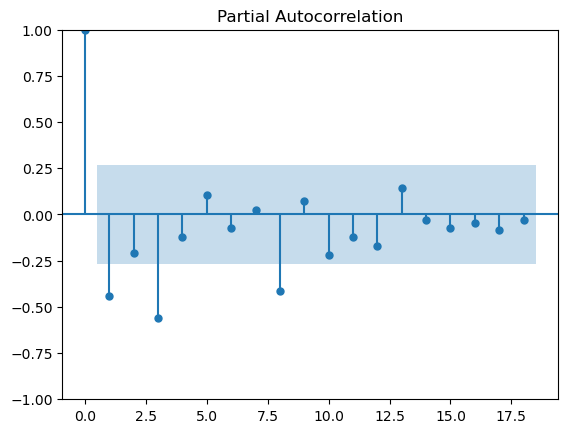

In [42]:
from statsmodels.tsa.stattools import pacf
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

pacf_array = pacf(train)
print(pacf_array)

#Grafico con un NC 95%
plot_pacf(train,alpha=0.05)
plt.show()

Parámetro base para la Media Móvil debería ser p = 1

[ 1.         -0.44117303  0.02758667 -0.35324923  0.39568997  0.0085918
 -0.08424938 -0.11569262 -0.15770705  0.44173189 -0.27912118  0.12274787
 -0.32953142  0.5008474  -0.26284662  0.09082642 -0.20743004  0.16970367]


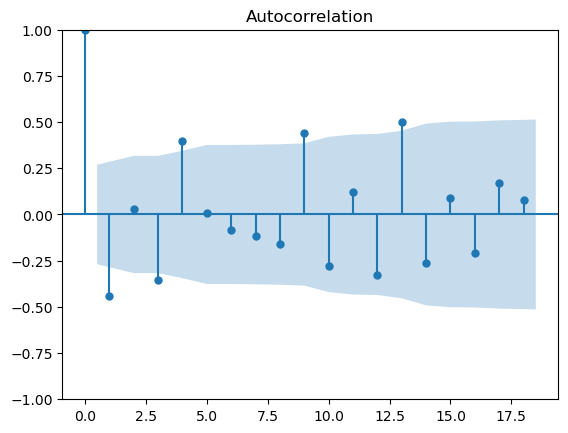

In [48]:
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

acf_array = acf(train)
print(acf_array)

#Grafico con un NC 95%
plot_acf(train,alpha=0.05)
plt.show()

Parámetro base para la Media Móvil debería ser q = 1 

Las ventas de Vanish tienen Estacionalidad

In [56]:
len_train_og = int(len(ts)*0.8)
train_og = ts[0:len_train_og]
test_og = ts[len_train_og:]

In [86]:
modelo_arima = ARIMA(train_og, order=(1, 1, 1))
resultados_arima = modelo_arima.fit()
print("--- RESUMEN DEL MODELO ARIMA ---")
print(resultados_arima.summary())

--- RESUMEN DEL MODELO ARIMA ---
                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   54
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -541.030
Date:                Sun, 12 Apr 2026   AIC                           1088.060
Time:                        23:59:06   BIC                           1093.971
Sample:                    03-28-2022   HQIC                          1090.333
                         - 04-03-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1354      0.188      0.719      0.472      -0.234       0.505
ma.L1         -0.4570      0.201     -2.275      0.023      -0.851      -0.063
sigma2      3.422e+

Como ar.L1 > 0.05 se procede a probar con configuración (0,1,1)

In [89]:
modelo_arima = ARIMA(train_og, order=(0, 1, 1))
resultados_arima = modelo_arima.fit()
print("--- RESUMEN DEL MODELO ARIMA ---")
print(resultados_arima.summary())

--- RESUMEN DEL MODELO ARIMA ---
                               SARIMAX Results                                
Dep. Variable:      TOTAL_VALUE_SALES   No. Observations:                   54
Model:                 ARIMA(0, 1, 1)   Log Likelihood                -541.137
Date:                Sun, 12 Apr 2026   AIC                           1086.274
Time:                        23:59:55   BIC                           1090.215
Sample:                    03-28-2022   HQIC                          1087.790
                         - 04-03-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3242      0.051     -6.318      0.000      -0.425      -0.224
sigma2       3.51e+07   1.42e-11   2.47e+18      0.000    3.51e+07    3.51e+07
Ljung-Box (L1) (Q):

In [93]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
modelo_sarima = SARIMAX(
    train_og, 
    order=(1, 1, 1),             
    seasonal_order=(1, 0, 1, 4),  
    enforce_stationarity=False,   
    enforce_invertibility=False
)
resultados_sarima = modelo_sarima.fit(disp=False)
print("--- RESUMEN DEL MODELO SARIMA ---")
print(resultados_sarima.summary())

--- RESUMEN DEL MODELO SARIMA ---
                                     SARIMAX Results                                     
Dep. Variable:                 TOTAL_VALUE_SALES   No. Observations:                   54
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 4)   Log Likelihood                -467.280
Date:                           Mon, 13 Apr 2026   AIC                            944.560
Time:                                   00:21:39   BIC                            953.811
Sample:                               03-28-2022   HQIC                           948.041
                                    - 04-03-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1097      0.177      0.618      0.537      -0.238       0.457
ma.L1    

Como ar.L1 > 0.05 se procede a probar con configuración (0,1,1)

In [84]:
modelo_sarima = SARIMAX(
    train_og, 
    order=(0, 1, 1),             
    seasonal_order=(1, 0, 1, 4),  
    enforce_stationarity=False,   
    enforce_invertibility=False
)
resultados_sarima = modelo_sarima.fit(disp=False)
print("--- RESUMEN DEL MODELO SARIMA ---")
print(resultados_sarima.summary())

--- RESUMEN DEL MODELO SARIMA ---
                                     SARIMAX Results                                     
Dep. Variable:                 TOTAL_VALUE_SALES   No. Observations:                   54
Model:             SARIMAX(0, 1, 1)x(1, 0, 1, 4)   Log Likelihood                -467.933
Date:                           Sun, 12 Apr 2026   AIC                            943.865
Time:                                   23:53:41   BIC                            951.266
Sample:                               03-28-2022   HQIC                           946.650
                                    - 04-03-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -1.0005      0.140     -7.138      0.000      -1.275      -0.726
ar.S.L4  

Como ar.S.L4 > 0.05 se prueba con la configuración estacional (0,0,1,4)

In [106]:
modelo_sarima = SARIMAX(
    train_og, 
    order=(0, 1, 1),             
    seasonal_order=(0, 0, 1, 4),  
    enforce_stationarity=False,   
    enforce_invertibility=False
)
resultados_sarima = modelo_sarima.fit(disp=False)
print("--- RESUMEN DEL MODELO SARIMA ---")
print(resultados_sarima.summary())

--- RESUMEN DEL MODELO SARIMA ---
                                     SARIMAX Results                                     
Dep. Variable:                 TOTAL_VALUE_SALES   No. Observations:                   54
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 4)   Log Likelihood                -468.175
Date:                           Mon, 13 Apr 2026   AIC                            942.350
Time:                                   00:29:17   BIC                            947.901
Sample:                               03-28-2022   HQIC                           944.439
                                    - 04-03-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9487      0.085    -11.186      0.000      -1.115      -0.783
ma.S.L4  

In [108]:
train_log = np.log(train_og)
modelo_sarima = SARIMAX(
    train_log, 
    order=(0, 1, 1),             
    seasonal_order=(0, 0, 1, 4),  
    enforce_stationarity=False,   
    enforce_invertibility=False
)
resultados_sarima = modelo_sarima.fit(disp=False)
print("--- RESUMEN DEL MODELO SARIMA ---")
print(resultados_sarima.summary())

--- RESUMEN DEL MODELO SARIMA ---
                                     SARIMAX Results                                     
Dep. Variable:                 TOTAL_VALUE_SALES   No. Observations:                   54
Model:             SARIMAX(0, 1, 1)x(0, 0, 1, 4)   Log Likelihood                  59.017
Date:                           Mon, 13 Apr 2026   AIC                           -112.033
Time:                                   00:30:57   BIC                           -106.483
Sample:                               03-28-2022   HQIC                          -109.945
                                    - 04-03-2023                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9405      0.114     -8.254      0.000      -1.164      -0.717
ma.S.L4  

In [112]:
pasos = len(test_og)
predicciones_log = resultados_sarima.forecast(steps=pasos)
predicciones_reales = np.exp(predicciones_log)
predicciones_reales.index = test_og.index


print("\nPredicciones para las próximas semanas:")
print(predicciones_reales)


Predicciones para las próximas semanas:
date
2023-04-10    68027.034746
2023-04-17    67958.461393
2023-04-24    67987.130586
2023-05-01    67324.978788
2023-05-08    67399.382728
2023-05-15    67399.382728
2023-05-22    67399.382728
2023-05-29    67399.382728
2023-06-05    67399.382728
2023-06-12    67399.382728
2023-06-19    67399.382728
2023-06-26    67399.382728
2023-07-03    67399.382728
2023-07-10    67399.382728
Freq: W-MON, Name: predicted_mean, dtype: float64


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


y_real = test_og.iloc[:, 0] if len(test.shape) > 1 else test
y_pred = predicciones

rmse = np.sqrt(mean_squared_error(y_real, y_pred))

mape = mean_absolute_percentage_error(y_real, y_pred) * 100

print(f"La raíz del error cuadrático medio (RMSE) es: {rmse:.4f}")
print(f"El margen de error porcentual (MAPE) es: {mape:.4f}%")

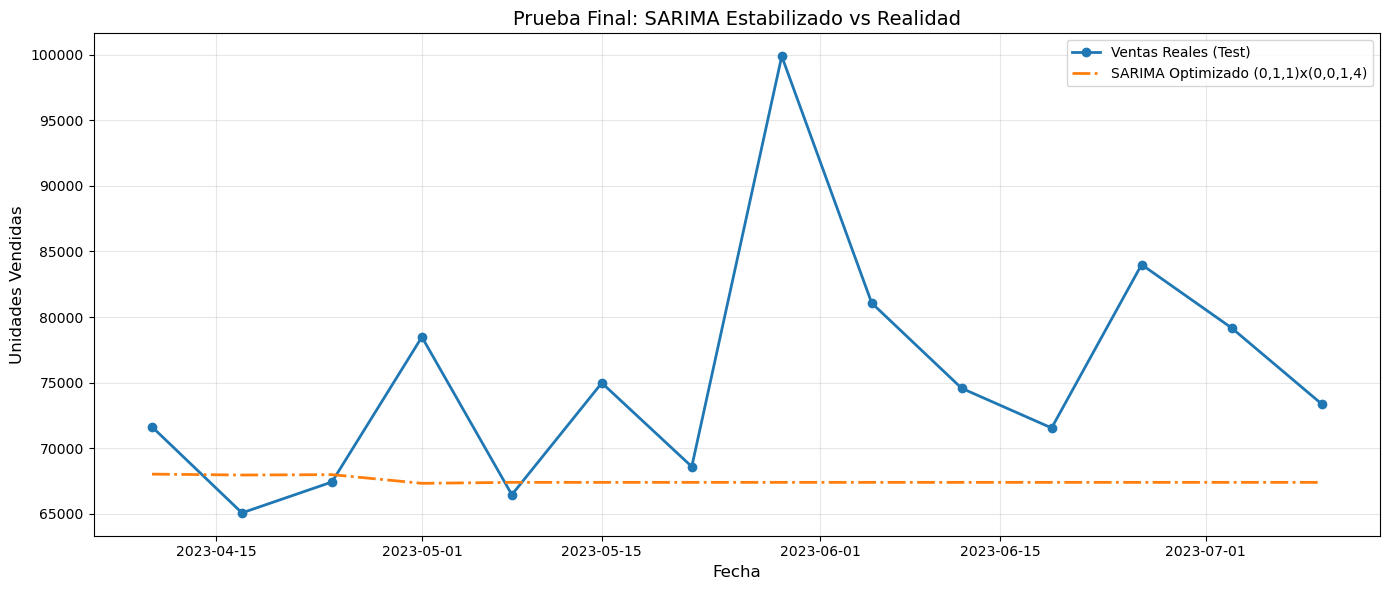

In [114]:
import matplotlib.pyplot as plt
import numpy as np

# 2. GRAFICAR
plt.figure(figsize=(14, 6))

# Línea de la Realidad (Tu set de Test)
plt.plot(test_og.index, test_og.values, label='Ventas Reales (Test)', linewidth=2, marker='o')

# Línea de tu nuevo súper modelo SARIMA
plt.plot(test_og.index, predicciones_reales, label='SARIMA Optimizado (0,1,1)x(0,0,1,4)', linestyle='-.', linewidth=2)

# Detalles estéticos
plt.title('Prueba Final: SARIMA Estabilizado vs Realidad', fontsize=14)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Unidades Vendidas', fontsize=12)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [122]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error


y_real = test_og.values
y_pred = predicciones_reales.values
rmse = np.sqrt(mean_squared_error(y_real, y_pred))
mape = mean_absolute_percentage_error(y_real, y_pred) * 100

print("REPORTE DE PRECISIÓN DEL MODELO SARIMAX")
print("-" * 40)
print(f"RMSE: {rmse:,.0f} unidades")
print(f"MAPE: {mape:.2f}% de margen de error promedio")

REPORTE DE PRECISIÓN DEL MODELO SARIMAX
----------------------------------------
RMSE: 11,854 unidades
MAPE: 10.39% de margen de error promedio


Conclusiones:
- Se detectó que la serie no era estacionaria por lo que se prefirio trabajar con modelos de series de tiempo
- Mediante los valores de AIC y BIC se trabajo con los modelos ARIMA y SARIMA con estacionalidad de 4 semanas. Donde se encontro que la configuración óptima fue (0,1,1)
- Las predicciones despues de cierto tiempo se estabilizan ya que el modelo solo tiene de memoria 1 día por lo que por agotamiento establece un precio constante en algun punto del futuro
- RMSE: 11,854 unidades es la diferencia con la realidad vs el pronóstico y MAPE: 10.39% por lo que somos capaces de predecir 89.61%
- Hay eventualidades que disparan las ventas que pueden comprenderse como variables exogenas, a pesar de que el modelo generado alcanzo un nivel aceptable para predecir, hay que entender que es necesario darle un peso a esas variables que hicieron crecer de manera inusual las ventas debido a que eventualidades como esta estan completamente fuera de cobertura por el modelo generado